# Dynex SDK - nBit Adder Native Gate Circuit Example

First we import the required packages:

In [1]:
from pennylane import numpy as np
import pennylane as qml
from dynex import DynexConfig, ComputeBackend, DynexCircuit

config = DynexConfig(compute_backend=ComputeBackend.QPU, qpu_model="apollo_rc1", use_notebook_output=True)

We define our circuit:

In [2]:
params = [3123456789 , 987654321 ] # two numbers to add

def Nqubits(a, b):
    mxVal = a + b
    return mxVal.bit_length()

wires = Nqubits(*params)

def Kfourier(k, wires):
    for j in range(len(wires)):
        qml.RZ(k * np.pi / (2**j), wires=wires[j])

def FullAdder(params, state=True):
    a, b = params
    wires = Nqubits(a, b)
    qml.BasisEmbedding(a, wires=range(wires))
    qml.QFT(wires=range(wires))
    Kfourier(b, range(wires))
    qml.adjoint(qml.QFT)(wires=range(wires))
    if state:
        return qml.state()
    else:
        return qml.sample()

We draw the circuit:

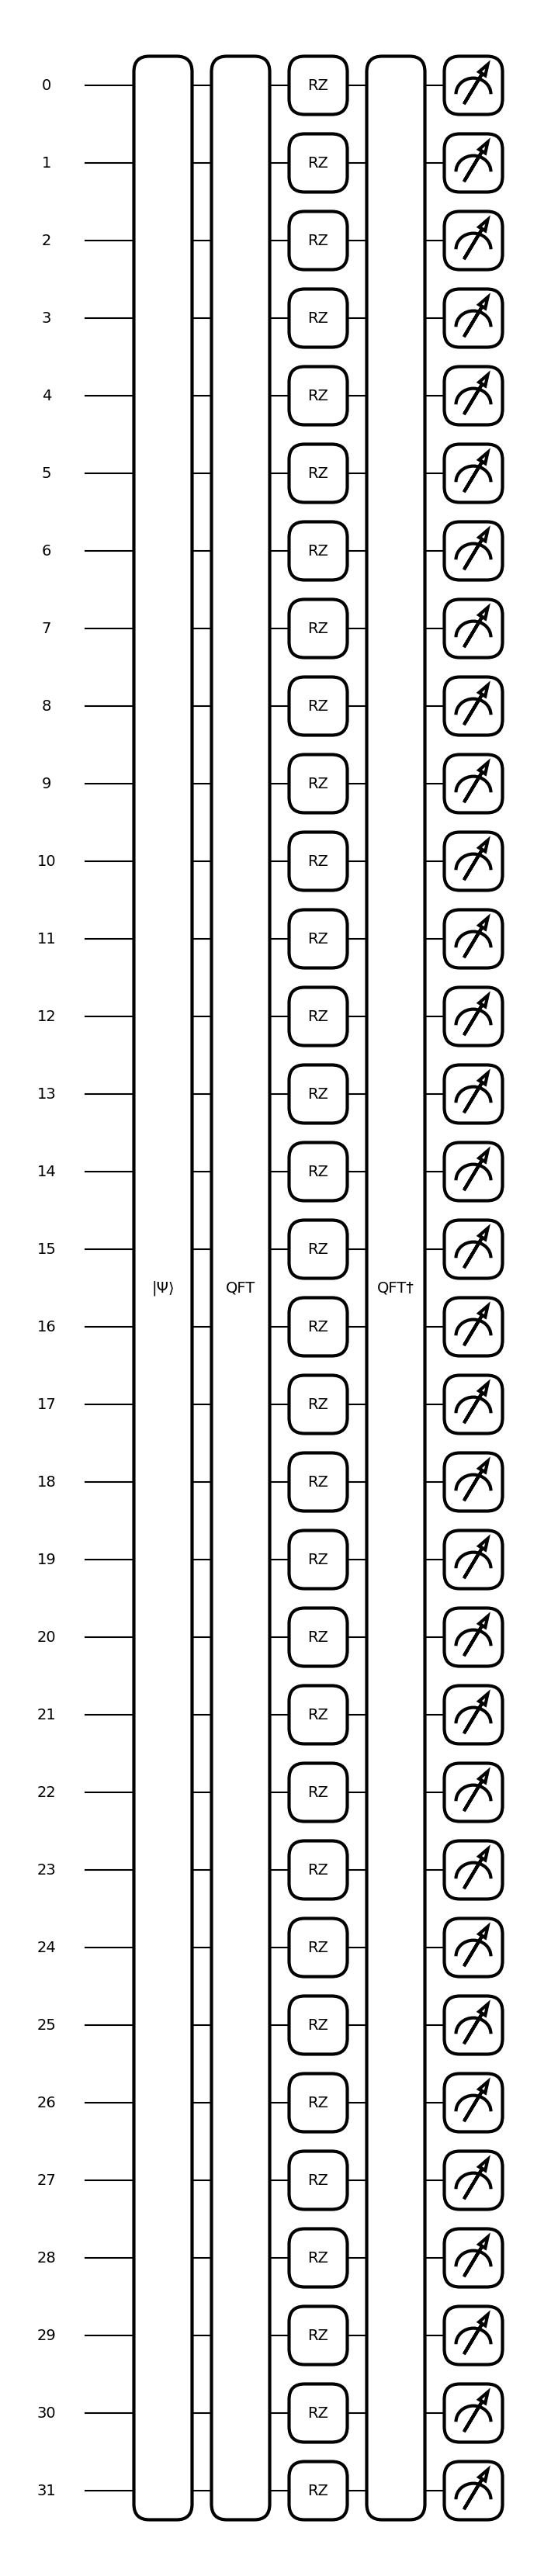

In [3]:
# draw circuit:
_ = qml.draw_mpl(FullAdder, style="black_white")(params)

We execute and measure the circuit on the Dynex platform:

In [4]:
# Execute the circuit on Dynex:
dynex_circuit = DynexCircuit(config=config)
measure = dynex_circuit.execute(FullAdder, params, wires, method="measure",
                                num_reads=1, integration_steps=10)
print("Mesaure:",measure)

INFO: [DYNEX-APOLLO-RC1] Executing PennyLane quantum circuit
INFO: [DYNEX-APOLLO-RC1] Sampler initialised
INFO: [DYNEX-APOLLO-RC1] Apollo QPU chip: apollo_rc1
INFO: [DYNEX-APOLLO-RC1] Settings: num_reads=1, shots=1, annealing_time=10
INFO: [DYNEX-APOLLO-RC1] Submitting the job to Dynex.
INFO: [DYNEX-APOLLO-RC1] SUCCESS: Job created successfully (job_id=7412)
INFO: [DYNEX-APOLLO-RC1] feed_dict: {'cos_rz_0': 6.147942102041399e-08, 'cos_rz_1': 0.7071068029228049, 'cos_rz_10': -0.9633657997970558, 'cos_rz_11': -0.13534068162039117, 'cos_rz_12': -0.657517801424269, 'cos_rz_13': 0.4138128795577362, 'cos_rz_14': -0.8407772831011006, 'cos_rz_15': 0.28215484835361193, 'cos_rz_16': -0.8006731069399083, 'cos_rz_17': 0.31569517977005257, 'cos_rz_18': 0.8110780417968584, 'cos_rz_19': 0.9515981404450248, 'cos_rz_2': 0.9238795383930756, 'cos_rz_20': -0.9878254249727086, 'cos_rz_21': -0.07802107095936126, 'cos_rz_22': 0.6789620493962232, 'cos_rz_23': -0.916231971008495, 'cos_rz_24': -0.204655844030295

Mesaure: [1 1 1 1 0 1 0 1 0 0 0 0 1 0 1 0 1 0 0 1 0 0 1 1 1 1 0 0 0 1 1 0]


In [5]:
bitStr = "".join(map(str, measure.astype(int)))
dynexResult = int(bitStr, 2)
print("Dynex Result:", dynexResult)
print("Expected Result:", sum(params))
isValidDynex = dynexResult == sum(params)
print("Is Dynex Result Valid?", isValidDynex)

Dynex Result: 4111111110
Expected Result: 4111111110
Is Dynex Result Valid? True
